In [1]:
import os
import pandas as pd
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG19, VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report

## If you dont have GPU or CUDA just remove the below cell

GPU run time --> 30 sec per run (approx --> 15 mins)

CPU run time --> 10 min per run (approx --> 5 hrs)

NOTE: these time might change according to your specs

In [2]:
# Allow GPU memory growth
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    for device in physical_devices:
        tf.config.experimental.set_memory_growth(device, True)

In [3]:
# Set the root directory for the dataset
root_dir = r'C:\Users\muruj\Music\Indii-Pakk\DATASET\augmented_dataset'

In [4]:
# List to store image paths and their corresponding class labels
image_paths = []
labels = []

In [5]:
# Loop over all the folders in the dataset directory
for class_folder in os.listdir(root_dir):
    class_folder_path = os.path.join(root_dir, class_folder)
    
    # Only process directories (make sure we're working with folders, not files)
    if os.path.isdir(class_folder_path):
        # Find all image files in the folder (assuming images have extensions like .jpg, .jpeg, .png, etc.)
        image_files = glob(os.path.join(class_folder_path, '*.*'))
        
        # Loop through all image files and append their path and class
        for image_file in image_files:
            image_paths.append(image_file)
            labels.append(class_folder)

In [6]:
# Create a DataFrame from the lists
df = pd.DataFrame({
    'image_path': image_paths,
    'class': labels
})

In [7]:
# Show the first few rows of the dataframe
print(df.head())

                                          image_path class
0  C:\Users\muruj\Music\Indii-Pakk\DATASET\augmen...   Ain
1  C:\Users\muruj\Music\Indii-Pakk\DATASET\augmen...   Ain
2  C:\Users\muruj\Music\Indii-Pakk\DATASET\augmen...   Ain
3  C:\Users\muruj\Music\Indii-Pakk\DATASET\augmen...   Ain
4  C:\Users\muruj\Music\Indii-Pakk\DATASET\augmen...   Ain


In [8]:
# Check the shape of the dataframe (i.e., total number of images)
print(f"Total number of images: {df.shape[0]}")

Total number of images: 34446


In [9]:
# Count the number of images per class (class distribution)
class_counts = df['class'].value_counts()
print(f"Number of images per class:\n{class_counts}")

Number of images per class:
class
Hay           1416
Toay_n        1029
Quaaf         1027
Zoay_n        1025
Dhuaad        1003
Tay            999
Gaaf           992
Djay           981
Jeem           980
Laam           979
Tey            976
Fay            975
Ghain          974
Kaaf           973
Chay           973
Zay            973
Hamza          971
Suaad          971
Khay           968
Seen           967
Noon           967
Ddaal          966
Daal           965
Bay            957
Chhoti yeh     948
Aliph          946
Vao            941
Meem           940
Bari yeh       936
Ain            935
Sheen          910
Thay           893
aRay           873
Pay            765
Dhaal          488
Ray            462
hey            402
Name: count, dtype: int64


C:\Users\muruj\AppData\Local\Temp\ipykernel_540\3485184553.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, order=class_counts.index, palette='Set2')


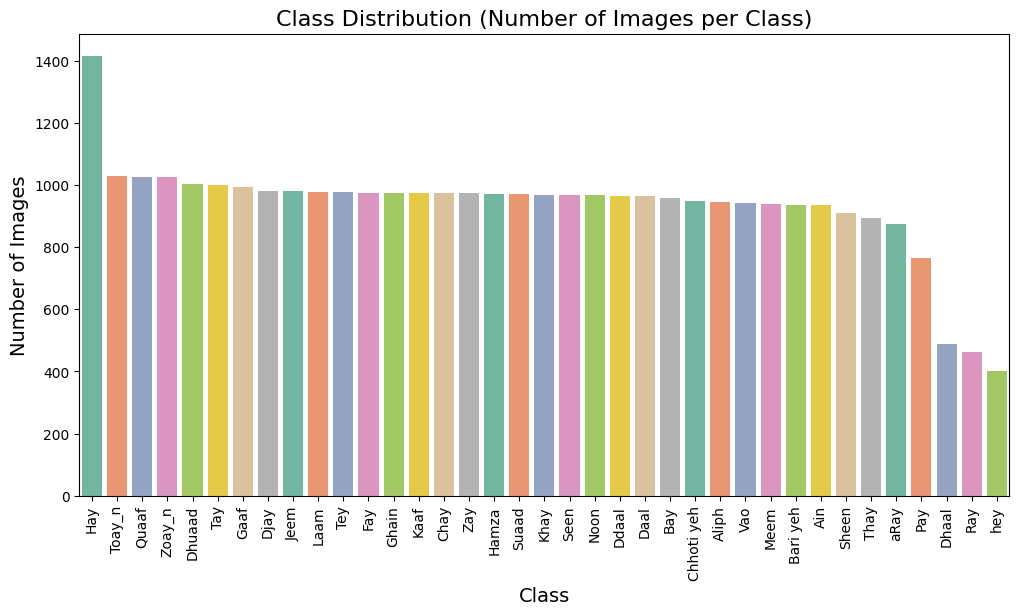

In [10]:
# Plot the distribution of classes
plt.figure(figsize=(12, 6))
sns.countplot(x='class', data=df, order=class_counts.index, palette='Set2')
plt.title('Class Distribution (Number of Images per Class)', fontsize=16)
plt.xlabel('Class', fontsize=14)
plt.ylabel('Number of Images', fontsize=14)
plt.xticks(rotation=90)
plt.show()

In [11]:
# Function to get image dimensions (height, width) of a few sample images
def get_image_dimensions(df, num_samples=10):
    image_dimensions = []
    
    # Randomly sample `num_samples` rows from the dataframe
    sample_df = df.sample(n=num_samples, random_state=42)
    
    for i, row in sample_df.iterrows():
        img = cv2.imread(row['image_path'])
        height, width, _ = img.shape
        image_dimensions.append((row['image_path'], height, width))
    
    # Display the dimensions
    return image_dimensions

# Get and display image dimensions
image_dimensions = get_image_dimensions(df)
print("Sample image dimensions (Path, Height, Width):")
for item in image_dimensions:
    print(item)

Sample image dimensions (Path, Height, Width):
('C:\\Users\\muruj\\Music\\Indii-Pakk\\DATASET\\augmented_dataset\\Laam\\aug_0_5074.jpg', 128, 128)
('C:\\Users\\muruj\\Music\\Indii-Pakk\\DATASET\\augmented_dataset\\Hamza\\aug_0_2012.jpg', 128, 128)
('C:\\Users\\muruj\\Music\\Indii-Pakk\\DATASET\\augmented_dataset\\Dhaal\\aug_0_1176.jpg', 128, 128)
('C:\\Users\\muruj\\Music\\Indii-Pakk\\DATASET\\augmented_dataset\\Tay\\aug_0_4322.jpg', 128, 128)
('C:\\Users\\muruj\\Music\\Indii-Pakk\\DATASET\\augmented_dataset\\Tay\\aug_0_9710.jpg', 128, 128)
('C:\\Users\\muruj\\Music\\Indii-Pakk\\DATASET\\augmented_dataset\\Hay\\aug_0_8055.jpg', 128, 128)
('C:\\Users\\muruj\\Music\\Indii-Pakk\\DATASET\\augmented_dataset\\Djay\\aug_0_2829.jpg', 128, 128)
('C:\\Users\\muruj\\Music\\Indii-Pakk\\DATASET\\augmented_dataset\\Aliph\\aug_0_4252.jpg', 128, 128)
('C:\\Users\\muruj\\Music\\Indii-Pakk\\DATASET\\augmented_dataset\\Ray\\aug_0_9128.jpg', 128, 128)
('C:\\Users\\muruj\\Music\\Indii-Pakk\\DATASET\\augmen

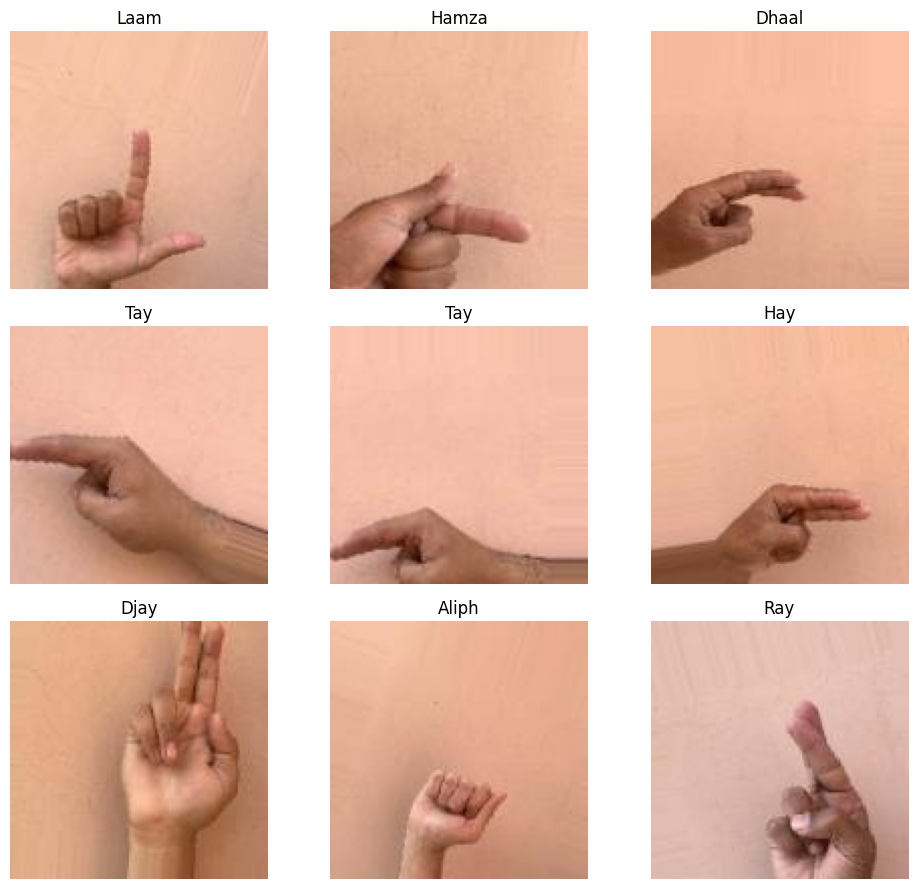

In [12]:
# Function to load and display a sample of images from the dataset
def plot_sample_images(df, num_samples=9):
    # Randomly sample `num_samples` rows from the dataframe
    sample_df = df.sample(n=num_samples, random_state=42)
    
    # Calculate number of rows and columns for the subplot grid
    rows = (num_samples // 3) + (1 if num_samples % 3 != 0 else 0)
    cols = 3 if num_samples > 3 else num_samples
    
    # Create the figure with appropriate size
    plt.figure(figsize=(10, rows * 3))
    
    # Loop through the sampled rows and plot images
    for idx, (i, row) in enumerate(sample_df.iterrows(), 1):  # Use idx to track subplot number
        img = cv2.imread(row['image_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert from BGR (OpenCV default) to RGB
        
        # Create subplot and plot image
        plt.subplot(rows, cols, idx)  # Use `idx` to set subplot index starting from 1
        plt.imshow(img)
        plt.axis('off')  # Hide axes
        plt.title(row['class'])
    
    # Display the images
    plt.tight_layout()
    plt.show()

# Example usage: Display 9 random sample images from your dataset
plot_sample_images(df, num_samples=9)

In [13]:
# Function to resample classes to 500 images per class by replicating images and store in a DataFrame
def resample_classes_to_dataframe(df, target_images_per_class=500):
    resampled_data = []  # This will store the image paths and class labels

    # Loop through each class and resample the images
    for class_label in df['class'].unique():
        # Get all images in the current class
        class_images = df[df['class'] == class_label]['image_path'].tolist()

        # If there are fewer than target images, replicate the images
        if len(class_images) < target_images_per_class:
            print(f"Replicating class: {class_label} to reach {target_images_per_class} images.")
            num_images_to_add = target_images_per_class - len(class_images)

            # Replicate images until we reach the target
            while num_images_to_add > 0:
                # Randomly pick an image to replicate
                image_to_replicate = random.choice(class_images)
                resampled_data.append([image_to_replicate, class_label])
                num_images_to_add -= 1
        else:
            print(f"Class {class_label} already has {len(class_images)} images, skipping replication.")
            # If the class already has 500 images, just add the images as is
            for image_path in class_images:
                resampled_data.append([image_path, class_label])

    # Create a DataFrame from the resampled data
    resampled_df = pd.DataFrame(resampled_data, columns=['image_path', 'class'])

    return resampled_df

In [14]:
# Example usage:
resampled_df = resample_classes_to_dataframe(df, target_images_per_class=500)

Class Ain already has 935 images, skipping replication.
Class Aliph already has 946 images, skipping replication.
Class aRay already has 873 images, skipping replication.
Class Bari yeh already has 936 images, skipping replication.
Class Bay already has 957 images, skipping replication.
Class Chay already has 973 images, skipping replication.
Class Chhoti yeh already has 948 images, skipping replication.
Class Daal already has 965 images, skipping replication.
Class Ddaal already has 966 images, skipping replication.
Replicating class: Dhaal to reach 500 images.
Class Dhuaad already has 1003 images, skipping replication.
Class Djay already has 981 images, skipping replication.
Class Fay already has 975 images, skipping replication.
Class Gaaf already has 992 images, skipping replication.
Class Ghain already has 974 images, skipping replication.
Class Hamza already has 971 images, skipping replication.
Class Hay already has 1416 images, skipping replication.
Replicating class: hey to re

In [15]:
# Check the first few rows of the resampled DataFrame
print(resampled_df.head())
print(f"Total images in the resampled DataFrame: {len(resampled_df)}")

                                          image_path class
0  C:\Users\muruj\Music\Indii-Pakk\DATASET\augmen...   Ain
1  C:\Users\muruj\Music\Indii-Pakk\DATASET\augmen...   Ain
2  C:\Users\muruj\Music\Indii-Pakk\DATASET\augmen...   Ain
3  C:\Users\muruj\Music\Indii-Pakk\DATASET\augmen...   Ain
4  C:\Users\muruj\Music\Indii-Pakk\DATASET\augmen...   Ain
Total images in the resampled DataFrame: 33242


In [16]:
resampled_df['class'].nunique()

37

In [17]:
# Label encode the classes
label_encoder = LabelEncoder()
resampled_df['encoded_class'] = label_encoder.fit_transform(resampled_df['class'])

In [18]:
# Save the label encoder to a pickle file
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

In [19]:
# Check the first few rows
print(resampled_df.head())

                                          image_path class  encoded_class
0  C:\Users\muruj\Music\Indii-Pakk\DATASET\augmen...   Ain              0
1  C:\Users\muruj\Music\Indii-Pakk\DATASET\augmen...   Ain              0
2  C:\Users\muruj\Music\Indii-Pakk\DATASET\augmen...   Ain              0
3  C:\Users\muruj\Music\Indii-Pakk\DATASET\augmen...   Ain              0
4  C:\Users\muruj\Music\Indii-Pakk\DATASET\augmen...   Ain              0


In [20]:
# Function to load and preprocess images
def preprocess_images(image_paths, target_size=(124, 124)):
    images = []
    for img_path in image_paths:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        img = cv2.resize(img, target_size)  # Resize to 124x124
        img = img / 255.0  # Normalize to [0, 1]
        images.append(img)
    return np.array(images)

In [21]:
# Preprocess the images for the entire dataset
X = preprocess_images(resampled_df['image_path'].tolist())

In [22]:
# Convert the encoded labels to numpy array
y = resampled_df['encoded_class'].values

In [23]:
print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")

Shape of X: (33242, 124, 124, 3), Shape of y: (33242,)


In [24]:
# Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [25]:
print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")

Training set shape: (26593, 124, 124, 3), Test set shape: (6649, 124, 124, 3)


In [26]:
# Load pre-trained VGG19 model (without the top classification layers)
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(124, 124, 3))

# Freeze the layers of VGG19
for layer in base_model.layers:
    layer.trainable = False

# Build the final model
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(len(label_encoder.classes_), activation='softmax')  # Number of classes
])

In [27]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [28]:
# Print the model summary to see the architecture
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 3, 3, 512)         20024384  
                                                                 
 flatten (Flatten)           (None, 4608)              0         
                                                                 
 dense (Dense)               (None, 512)               2359808   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 37)                18981     
                                                                 
Total params: 22,403,173
Trainable params: 2,378,789
Non-trainable params: 20,024,384
_________________________________________________________________


In [29]:
# Early Stopping: Monitor validation loss, and stop if it doesn't improve for 'patience' epochs
early_stopping = EarlyStopping(monitor='val_loss', 
                               patience=5, 
                               restore_best_weights=True, 
                               verbose=1)

In [30]:
# Learning Rate Scheduler: Reduce learning rate if the validation loss doesn't improve
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', 
                                  factor=0.5,  # Reduce the LR by half
                                  patience=3,  # Wait for 3 epochs with no improvement
                                  verbose=1, 
                                  min_lr=1e-6)  # Minimum LR value

In [ ]:
# Train the model with Early Stopping and Learning Rate Scheduler
history = model.fit(X_train, 
                    y_train, 
                    validation_data=(X_test, y_test), 
                    epochs=25,  # Train for up to 25 epochs (Early Stopping will stop it earlier if needed)
                    batch_size=32,
                    callbacks=[early_stopping, lr_scheduler])  # Include the callbacks

Epoch 1/25
832/832 [==============================] - 48s 51ms/step - loss: 2.1345 - accuracy: 0.4534 - val_loss: 1.1056 - val_accuracy: 0.8057 - lr: 1.0000e-04
Epoch 2/25
832/832 [==============================] - 38s 46ms/step - loss: 0.9748 - accuracy: 0.7567 - val_loss: 0.6066 - val_accuracy: 0.9001 - lr: 1.0000e-04
Epoch 3/25
832/832 [==============================] - 38s 46ms/step - loss: 0.6500 - accuracy: 0.8382 - val_loss: 0.4190 - val_accuracy: 0.9272 - lr: 1.0000e-04
Epoch 4/25
832/832 [==============================] - 38s 46ms/step - loss: 0.4789 - accuracy: 0.8823 - val_loss: 0.3181 - val_accuracy: 0.9398 - lr: 1.0000e-04
Epoch 5/25
832/832 [==============================] - 38s 46ms/step - loss: 0.3763 - accuracy: 0.9057 - val_loss: 0.2511 - val_accuracy: 0.9478 - lr: 1.0000e-04
Epoch 6/25
832/832 [==============================] - 38s 46ms/step - loss: 0.3089 - accuracy: 0.9220 - val_loss: 0.2046 - val_accuracy: 0.9607 - lr: 1.0000e-04
Epoch 7/25
832/832 [==============

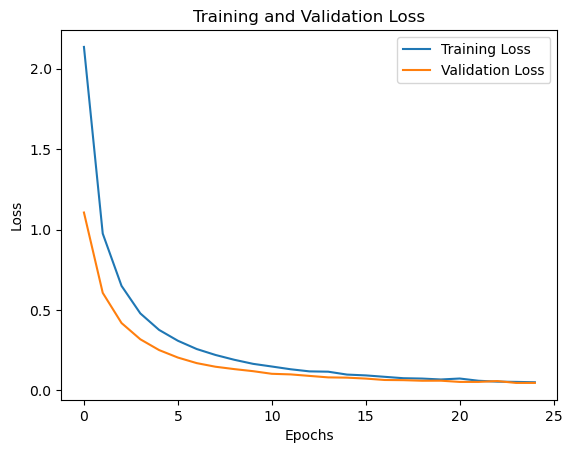

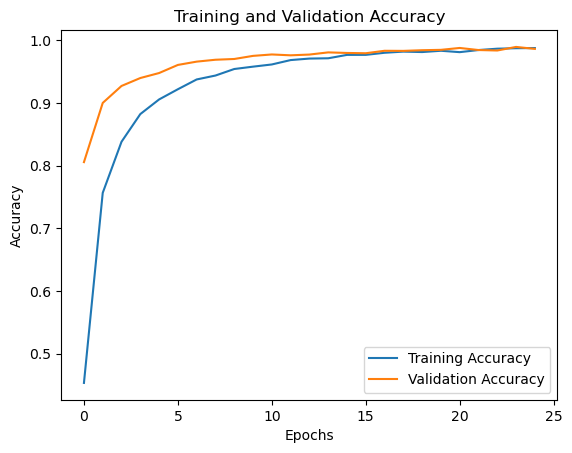

In [32]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

208/208 [==============================] - 7s 35ms/step
Classification Report:

              precision    recall  f1-score   support

         Ain       0.99      0.99      0.99       187
       Aliph       0.99      0.99      0.99       189
    Bari yeh       0.99      0.96      0.98       187
         Bay       1.00      0.99      0.99       191
        Chay       0.99      0.99      0.99       195
  Chhoti yeh       1.00      0.99      1.00       190
        Daal       1.00      0.98      0.99       193
       Ddaal       1.00      0.99      0.99       193
       Dhaal       1.00      1.00      1.00         2
      Dhuaad       0.97      1.00      0.98       201
        Djay       0.98      0.96      0.97       196
         Fay       0.97      0.98      0.98       195
        Gaaf       0.98      0.99      0.99       198
       Ghain       0.99      0.99      0.99       195
       Hamza       0.98      1.00      0.99       194
         Hay       0.94      1.00      0.97       283
 

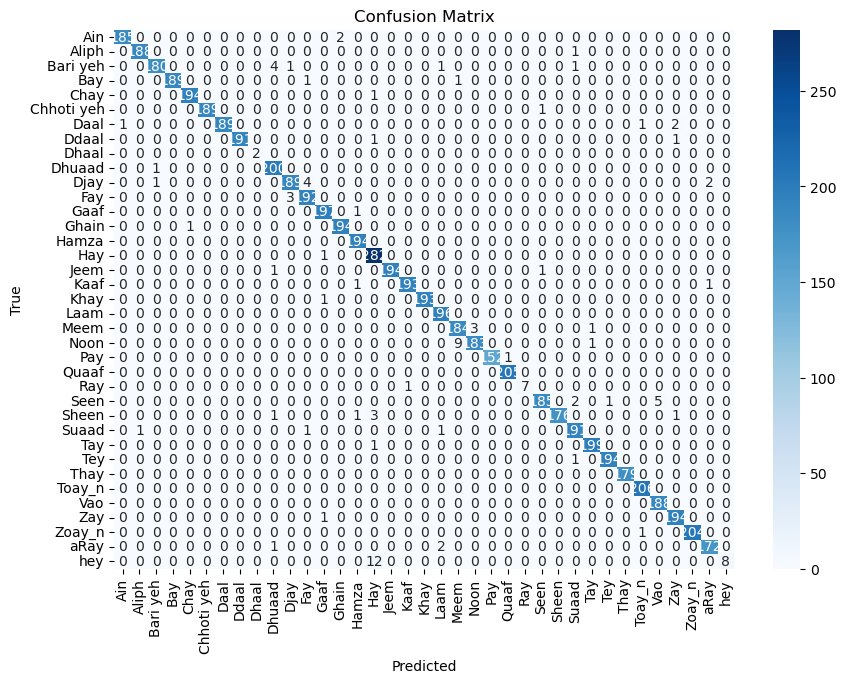

In [33]:
# Predict on the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Generate classification report
report = classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_)
print("Classification Report:\n")
print(report)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [34]:
model.save('vgg19.keras')

In [ ]:
# Load the pre-trained VGG16 model without the top classification layers
base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(124, 124, 3))

# Freeze the layers of the VGG16 model to avoid updating them during training
for layer in base_model_vgg.layers:
    layer.trainable = False

# Build the final model
vgg_model = Sequential([
    base_model_vgg,  # Add the VGG16 base model
    Flatten(),   # Flatten the output of VGG16 for the fully connected layers
    Dense(512, activation='relu'),  # Fully connected layer with 512 units
    Dropout(0.5),  # Dropout to prevent overfitting
    Dense(len(label_encoder.classes_), activation='softmax')  # Output layer (number of classes)
])

In [36]:
# Compile the model with the Adam optimizer and sparse categorical crossentropy loss
vgg_model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [37]:
# Print the model summary to see the architecture
vgg_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 3, 3, 512)         14714688  
                                                                 
 flatten_1 (Flatten)         (None, 4608)              0         
                                                                 
 dense_2 (Dense)             (None, 512)               2359808   
                                                                 
 dropout_1 (Dropout)         (None, 512)               0         
                                                                 
 dense_3 (Dense)             (None, 37)                18981     
                                                                 
Total params: 17,093,477
Trainable params: 2,378,789
Non-trainable params: 14,714,688
_________________________________________________________________


In [38]:
# from tensorflow.keras import backend as K
# K.clear_session()

In [ ]:
# Train the model with Early Stopping and Learning Rate Scheduler
history_vgg = vgg_model.fit(X_train, 
                                  y_train, 
                                  validation_data=(X_test, y_test), 
                                  epochs=30,  # Train for a maximum of 30 epochs
                                  batch_size=32, 
                                  callbacks=[early_stopping, lr_scheduler])  # Using both callbacks

Epoch 1/30
832/832 [==============================] - 35s 42ms/step - loss: 1.6505 - accuracy: 0.5798 - val_loss: 0.6717 - val_accuracy: 0.8902 - lr: 1.0000e-04
Epoch 2/30
832/832 [==============================] - 34s 40ms/step - loss: 0.6111 - accuracy: 0.8548 - val_loss: 0.3536 - val_accuracy: 0.9444 - lr: 1.0000e-04
Epoch 3/30
832/832 [==============================] - 34s 41ms/step - loss: 0.3728 - accuracy: 0.9154 - val_loss: 0.2232 - val_accuracy: 0.9642 - lr: 1.0000e-04
Epoch 4/30
832/832 [==============================] - 34s 41ms/step - loss: 0.2656 - accuracy: 0.9388 - val_loss: 0.1703 - val_accuracy: 0.9689 - lr: 1.0000e-04
Epoch 5/30
832/832 [==============================] - 34s 40ms/step - loss: 0.1982 - accuracy: 0.9558 - val_loss: 0.1282 - val_accuracy: 0.9780 - lr: 1.0000e-04
Epoch 6/30
832/832 [==============================] - 34s 40ms/step - loss: 0.1602 - accuracy: 0.9619 - val_loss: 0.1049 - val_accuracy: 0.9797 - lr: 1.0000e-04
Epoch 7/30
832/832 [==============

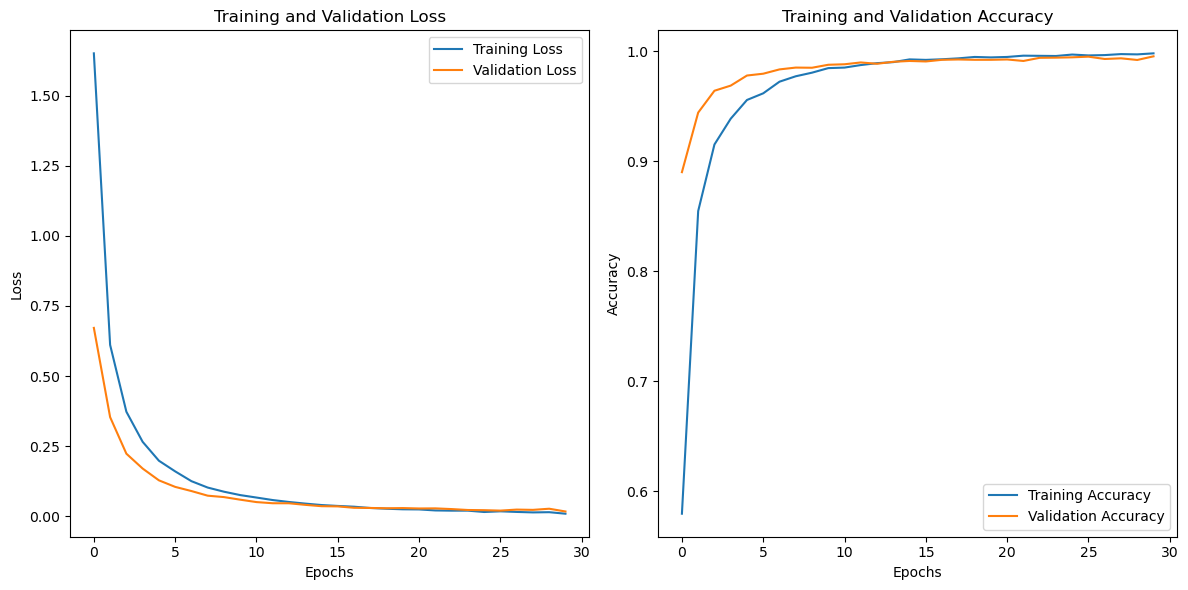

In [40]:
# --- Plot Training History (Loss & Accuracy) ---
plt.figure(figsize=(12, 6))

# Plot Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['loss'], label='Training Loss')
plt.plot(history_vgg.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()

208/208 [==============================] - 7s 31ms/step
Classification Report (ResNet50):

              precision    recall  f1-score   support

         Ain       1.00      1.00      1.00       187
       Aliph       1.00      1.00      1.00       189
    Bari yeh       0.99      1.00      0.99       187
         Bay       0.99      0.99      0.99       191
        Chay       0.99      0.99      0.99       195
  Chhoti yeh       1.00      0.99      0.99       190
        Daal       1.00      0.99      1.00       193
       Ddaal       1.00      0.99      1.00       193
       Dhaal       1.00      1.00      1.00         2
      Dhuaad       0.99      1.00      0.99       201
        Djay       1.00      0.99      1.00       196
         Fay       1.00      0.99      1.00       195
        Gaaf       1.00      0.99      0.99       198
       Ghain       1.00      1.00      1.00       195
       Hamza       0.99      1.00      1.00       194
         Hay       0.97      0.99      0.98 

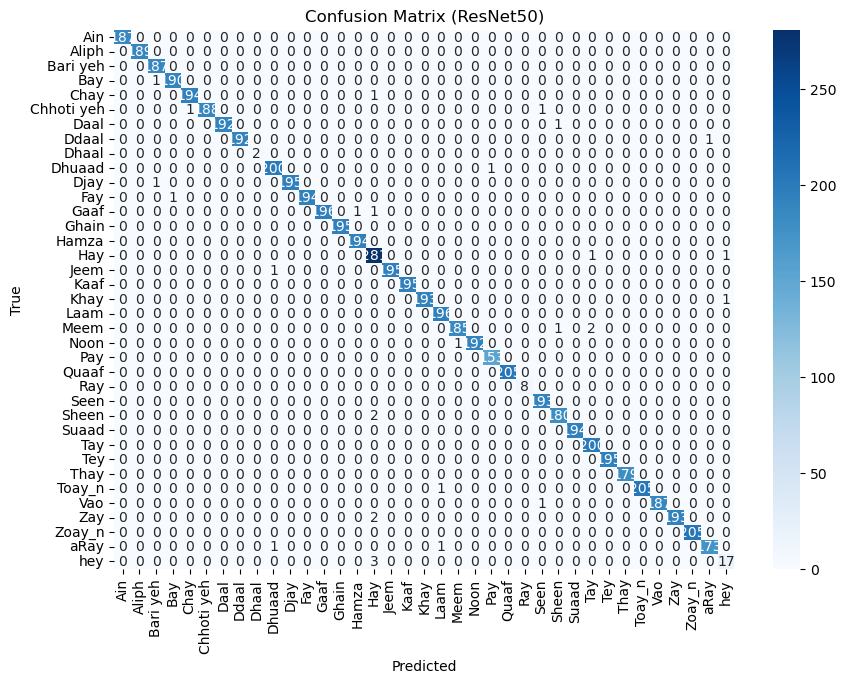

In [41]:
# Predict on the test set
y_pred_vgg = vgg_model.predict(X_test)
y_pred_classes_vgg = np.argmax(y_pred_vgg, axis=1)  # Convert probabilities to class labels

# Generate classification report
report_resnet = classification_report(y_test, y_pred_classes_vgg, target_names=label_encoder.classes_)
print("Classification Report (ResNet50):\n")
print(report_resnet)

# Compute confusion matrix
cm_resnet = confusion_matrix(y_test, y_pred_classes_vgg)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm_resnet, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (ResNet50)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [42]:
vgg_model.save('vgg16.keras')